# Resource-Rational Navigation in a k-ary Labyrinth
This notebook compares the metabolic cost of a **Cognitive Map (Q-Learning)** against a **Local Heuristic (Branch Bias)** agent. 

The total metabolic cost accounts for the sample inefficiency of learning the map and the dynamic allocation of memory:
$$C_{Total} = \sum (N_{Steps} \times E_{move}) + (B_{Memory} \times E_{comp})$$

In [1]:
# imports
import numpy as np
import matplotlib.pyplot as plt
from labyrinth import LabyrinthEnv
from Agent import QLearning_agent, HeuristicAgent

In [2]:
def heuristic_vs_map_experiment(k=2, depth=6, E_move=1.0, E_comp=10.0, verbose=True):
    env = LabyrinthEnv(k=k, depth=depth)
    num_states = env.observation_space.n
    num_actions = env.action_space.n
    optimal_steps = depth * 2 
    
    # EVALUATE MAP AGENT (Q-Learning)
    map_agent = QLearning_agent(num_states, num_actions)
    cumulative_map_steps = 0
    visited_states = set()
    consecutive_perfect_runs = 0
    episodes_to_mastery = 0
    
    for ep in range(5000): 
        obs, info = env.reset()
        done = False
        steps_this_episode = 0
        
        while not done and steps_this_episode < 2000:
            visited_states.add(obs)
            action = map_agent.choose_action(obs)
            next_obs, reward, done, truncated, next_info = env.step(action)
            
            map_agent.learn(obs, action, reward, next_obs, done)
            obs = next_obs
            steps_this_episode += 1
            cumulative_map_steps += 1
            
        episodes_to_mastery += 1
        
        # Force the agent to reduce random exploration even if it timed out
        map_agent.epsilon = max(map_agent.min_epsilon, map_agent.epsilon * map_agent.epsilon_decay)
            
        if steps_this_episode == optimal_steps:
            consecutive_perfect_runs += 1
        else:
            consecutive_perfect_runs = 0
            
        if consecutive_perfect_runs >= 5:
            break
            
    dynamic_memory_bits = len(visited_states) * num_actions * 32
    map_total_cost = (cumulative_map_steps * E_move) + (dynamic_memory_bits * E_comp)
    
    # ==========================================================
    # 2. EVALUATE HEURISTIC AGENT
    # ==========================================================
    heur_agent = HeuristicAgent(k_actions=k)
    heur_memory_bits = heur_agent.memory_bits 
    
    max_allowed_steps = (map_total_cost - (heur_memory_bits * E_comp)) / E_move
    step_limit = min(max_allowed_steps + 10, 500000) 
    
    heur_runs = 100
    total_heur_steps = 0
    hit_early_stop = False
    
    for _ in range(heur_runs):
        obs, info = env.reset()
        done = False
        steps = 0
        
        while not done and steps < step_limit:
            action = heur_agent.choose_action(obs, info['has_water'], info['at_dead_end'])
            obs, reward, done, truncated, info = env.step(action)
            steps += 1
            
        if steps >= step_limit:
            hit_early_stop = True
            
        total_heur_steps += steps
        
    avg_heur_steps = total_heur_steps / heur_runs
    heur_total_cost = (avg_heur_steps * E_move) + (heur_memory_bits * E_comp)
    
    # ==========================================================
    # 3. PRINT RESULTS
    # ==========================================================
    if verbose:
        print(f"Map Cost: {map_total_cost:,.0f} | Heuristic Cost: {heur_total_cost:,.0f}")
        if hit_early_stop:
            print(f"⚠️ EARLY STOP TRIGGERED: Heuristics got lost and exceeded Map Cost.")
            
    return map_total_cost, heur_total_cost

## Phase 1: Replicating Rosenberg et al. (k=2)
Running the baseline experiment on a binary tree labyrinth to verify that local heuristics are metabolically cheaper than building a cognitive map during the exploration phase.

In [3]:
# Run the binary tree (k=2) labyrinth
# Assuming a single step is cheap (1.0), but brain maintenance is expensive (10.0)
cost_map, cost_heur = heuristic_vs_map_experiment(k=2, depth=6, E_move=1.0, E_comp=10.0, verbose=True)

Map Cost: 194,382 | Heuristic Cost: 177,253
⚠️ EARLY STOP TRIGGERED: Heuristics got lost and exceeded Map Cost.


### Phase 1 (A): Changing the binary tree labyrinth depth
Running a k=2 labyrinth with a depth of 3

In [4]:
cost_map, cost_heur = heuristic_vs_map_experiment(k=2, depth=3, E_move=1.0, E_comp=10.0, verbose=True)

Map Cost: 22,499 | Heuristic Cost: 2,070


In [5]:
cost_map, cost_heur = heuristic_vs_map_experiment(k=2, depth=4, E_move=1.0, E_comp=10.0, verbose=True)

Map Cost: 47,498 | Heuristic Cost: 17,303
⚠️ EARLY STOP TRIGGERED: Heuristics got lost and exceeded Map Cost.



--- STEP-BY-STEP LOG: HEURISTIC AGENT (k=2, depth=3) ---
 Step  Node Dead End? Has Water?          Action Taken
    0     0        No         No            Reverse ↩️
    1     0        No         No Forward (Branch 1) ➡️
    2     2        No         No Forward (Branch 0) ➡️
    3     5        No         No Forward (Branch 1) ➡️
    4    12       Yes         No            Reverse ↩️
    5     5        No         No Forward (Branch 0) ➡️
    6    11       Yes         No            Reverse ↩️
    7     5        No         No Forward (Branch 1) ➡️
    8    12       Yes         No            Reverse ↩️
    9     5        No         No Forward (Branch 0) ➡️
   10    11       Yes         No            Reverse ↩️
   11     5        No         No Forward (Branch 1) ➡️
   12    12       Yes         No            Reverse ↩️
   13     5        No         No Forward (Branch 0) ➡️
   14    11       Yes         No            Reverse ↩️
   15     5        No         No Forward (Branch 1) ➡️
   16  

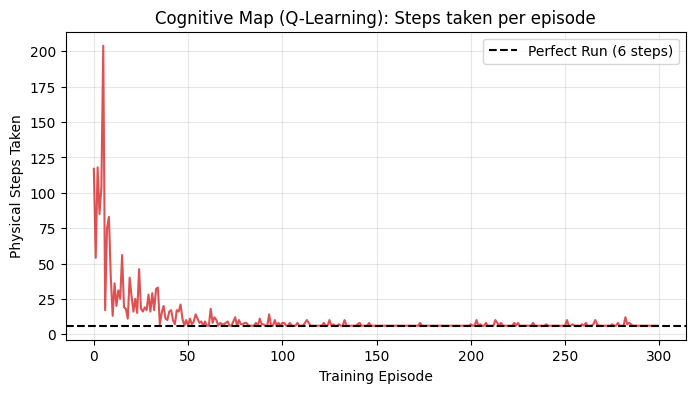

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from labyrinth import LabyrinthEnv
from Agent import QLearning_agent, HeuristicAgent

def watch_heuristic_mouse(k=2, depth=3):
    print(f"\n--- STEP-BY-STEP LOG: HEURISTIC AGENT (k={k}, depth={depth}) ---")
    env = LabyrinthEnv(k=k, depth=depth)
    agent = HeuristicAgent(k_actions=k)
    
    obs, info = env.reset()
    done = False
    step_count = 0
    log = []
    
    while not done and step_count < 100:
        action = agent.choose_action(obs, info['has_water'], info['at_dead_end'])
        
        # Translate the action into readable English
        if action == k:
            action_str = "Reverse ↩️"
        else:
            action_str = f"Forward (Branch {action}) ➡️"
            
        log.append({
            "Step": step_count,
            "Node": info['node'],
            "Dead End?": "Yes" if info['at_dead_end'] else "No",
            "Has Water?": "Yes 💧" if info['has_water'] else "No",
            "Action Taken": action_str
        })
        
        obs, reward, done, truncated, info = env.step(action)
        step_count += 1
        
    # Append the final state
    log.append({
        "Step": step_count,
        "Node": info['node'],
        "Dead End?": "-",
        "Has Water?": "Yes 💧",
        "Action Taken": "🎉 ESCAPED!" if done else "TIMEOUT"
    })
    
    # Print as a nice table
    df = pd.DataFrame(log)
    print(df.to_string(index=False))


def watch_map_agent_learning(k=2, depth=3):
    print(f"\n--- LEARNING CURVE: MAP AGENT (k={k}, depth={depth}) ---")
    env = LabyrinthEnv(k=k, depth=depth)
    agent = QLearning_agent(env.observation_space.n, env.action_space.n)
    
    episode_lengths = []
    
    for ep in range(300): # Watch it for 300 episodes
        obs, info = env.reset()
        done = False
        steps = 0
        
        while not done and steps < 500:
            action = agent.choose_action(obs)
            next_obs, reward, done, truncated, next_info = env.step(action)
            agent.learn(obs, action, reward, next_obs, done)
            obs = next_obs
            steps += 1
            
        # Manually decay epsilon
        agent.epsilon = max(agent.min_epsilon, agent.epsilon * agent.epsilon_decay)
        episode_lengths.append(steps)

    # Plot the learning progression
    plt.figure(figsize=(8, 4))
    plt.plot(episode_lengths, color='#D62728', alpha=0.8)
    plt.title('Cognitive Map (Q-Learning): Steps taken per episode', fontsize=12)
    plt.xlabel('Training Episode')
    plt.ylabel('Physical Steps Taken')
    plt.axhline(y=depth*2, color='black', linestyle='--', label='Perfect Run (6 steps)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Run the diagnostics!
watch_heuristic_mouse(k=2, depth=3)
watch_map_agent_learning(k=2, depth=3)

## Phase 2: The Extension (Scaling the Branching Factor)
What happens when the environment becomes too complex? By scaling the branching factor $k$, we track the exact point where the environment becomes so dense that heuristics cause endless wandering, forcing the agent to rely on a cognitive map.

In [ ]:
# We test k values from 2 to 4
k_values = [2, 3, 4]
map_costs = []
heur_costs = []

for k in k_values:
    c_map, c_heur = heuristic_vs_map_experiment(k=k, depth=4, E_move=1.0, E_comp=10.0, verbose=False)
    map_costs.append(c_map)
    heur_costs.append(c_heur)
    print(f"Finished k={k} -> Map Cost: {c_map:.0f} | Heuristic Cost: {c_heur:.0f}")

# Plotting the Phase Transition
plt.figure(figsize=(8, 5))
plt.plot(k_values, map_costs, marker='o', label='Cognitive Map', color='red', linewidth=2)
plt.plot(k_values, heur_costs, marker='s', label='Heuristic Rules', color='blue', linewidth=2)

plt.title('Metabolic Cost Transition as Maze Complexity Increases', fontsize=14)
plt.xlabel('Branching Factor (k)', fontsize=12)
plt.ylabel('Total Metabolic Cost', fontsize=12)
plt.xticks(k_values)
plt.yscale('log') # Log scale helps visualize exponential explosions
plt.legend(fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.show()